In [2]:
# 텐서플로 라이브러리 안에 있는 케라스 API에서 필요한 함수들을 불러옵니다.
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense   

# 데이터를 다루는 데 필요한 라이브러리를 불러옵니다.
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("./pima-indians-diabetes3.csv")
df

# | 컬럼                       | 의미         |
# | ------------------------ | ---------- |
# | Pregnancies              | 임신 횟수      |
# | Glucose                  | 혈당 수치      |
# | BloodPressure            | 혈압         |
# | SkinThickness            | 피부 두께      |
# | Insulin                  | 인슐린 수치     |
# | BMI                      | 체질량지수      |
# | DiabetesPedigreeFunction | 당뇨 유전 지수   |
# | Age                      | 나이         |
# | Outcome                  | 당뇨병 여부(정답) |

df.info()

print(df["diabetes"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pregnant   768 non-null    int64  
 1   plasma     768 non-null    int64  
 2   pressure   768 non-null    int64  
 3   thickness  768 non-null    int64  
 4   insulin    768 non-null    int64  
 5   bmi        768 non-null    float64
 6   pedigree   768 non-null    float64
 7   age        768 non-null    int64  
 8   diabetes   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
diabetes
0    500
1    268
Name: count, dtype: int64


In [4]:
print(df.describe())

         pregnant      plasma    pressure  ...    pedigree         age    diabetes
count  768.000000  768.000000  768.000000  ...  768.000000  768.000000  768.000000
mean     3.845052  120.894531   69.105469  ...    0.471876   33.240885    0.348958
std      3.369578   31.972618   19.355807  ...    0.331329   11.760232    0.476951
min      0.000000    0.000000    0.000000  ...    0.078000   21.000000    0.000000
25%      1.000000   99.000000   62.000000  ...    0.243750   24.000000    0.000000
50%      3.000000  117.000000   72.000000  ...    0.372500   29.000000    0.000000
75%      6.000000  140.250000   80.000000  ...    0.626250   41.000000    1.000000
max     17.000000  199.000000  122.000000  ...    2.420000   81.000000    1.000000

[8 rows x 9 columns]


In [5]:
print(df.corr())

           pregnant    plasma  pressure  ...  pedigree       age  diabetes
pregnant   1.000000  0.129459  0.141282  ... -0.033523  0.544341  0.221898
plasma     0.129459  1.000000  0.152590  ...  0.137337  0.263514  0.466581
pressure   0.141282  0.152590  1.000000  ...  0.041265  0.239528  0.065068
thickness -0.081672  0.057328  0.207371  ...  0.183928 -0.113970  0.074752
insulin   -0.073535  0.331357  0.088933  ...  0.185071 -0.042163  0.130548
bmi        0.017683  0.221071  0.281805  ...  0.140647  0.036242  0.292695
pedigree  -0.033523  0.137337  0.041265  ...  1.000000  0.033561  0.173844
age        0.544341  0.263514  0.239528  ...  0.033561  1.000000  0.238356
diabetes   0.221898  0.466581  0.065068  ...  0.173844  0.238356  1.000000

[9 rows x 9 columns]


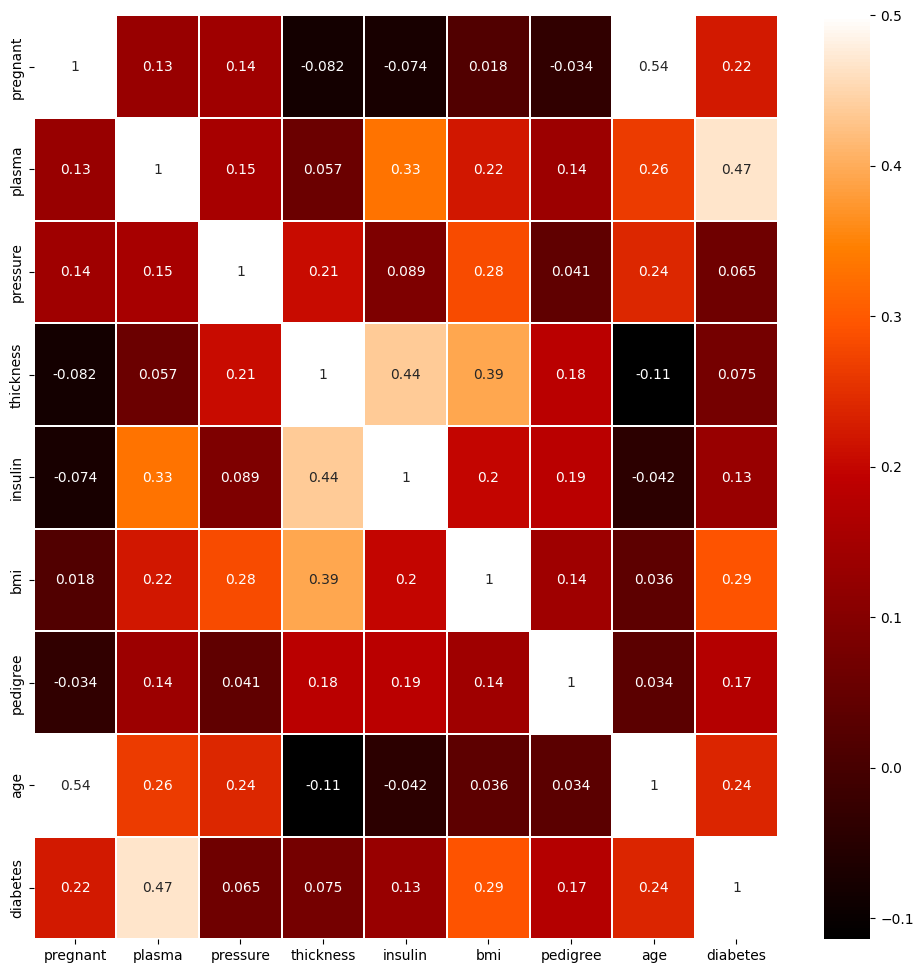

In [6]:
#필요한 라이브러리를 불러옵니다.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 간의 상관 관계를 그래프로 표현해 봅니다.
colormap = plt.cm.gist_heat   #그래프의 색상 구성을 정합니다.
plt.figure(figsize=(12,12))   #그래프의 크기를 정합니다.

# 그래프의 속성을 결정합니다. vmax의 값을 0.5로 지정해 0.5에 가까울수록 밝은색으로 표시되게 합니다.
sns.heatmap(df.corr(),linewidths=0.1,vmax=0.5, cmap=colormap, linecolor='white', annot=True)
plt.show()

In [7]:
# 데이터 나누기

# 세부 정보를 X로 지정합니다.
x = df.iloc[ : , 0:8]

# 당뇨병 여부를 Y로 지정합니다.
y = df.iloc[ : , 8]

print(x)
print(y)

     pregnant  plasma  pressure  thickness  insulin   bmi  pedigree  age
0           6     148        72         35        0  33.6     0.627   50
1           1      85        66         29        0  26.6     0.351   31
2           8     183        64          0        0  23.3     0.672   32
3           1      89        66         23       94  28.1     0.167   21
4           0     137        40         35      168  43.1     2.288   33
..        ...     ...       ...        ...      ...   ...       ...  ...
763        10     101        76         48      180  32.9     0.171   63
764         2     122        70         27        0  36.8     0.340   27
765         5     121        72         23      112  26.2     0.245   30
766         1     126        60          0        0  30.1     0.349   47
767         1      93        70         31        0  30.4     0.315   23

[768 rows x 8 columns]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
N

In [12]:
# 학습용/테스트용 데이터 분리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# 정상 : 980명
# 암환자 : 20명

# 정상 : 200명
# 암환자 : 0명
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify=y # 같은 비율로 들어갈 수 있도록 # 분류 모델에서는 stratify=y 로 할 것
)

# 정규화
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5092 - loss: 0.7241 - val_accuracy: 0.6667 - val_loss: 0.6774
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6884 - loss: 0.6252 - val_accuracy: 0.6667 - val_loss: 0.6011
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7189 - loss: 0.5763 - val_accuracy: 0.7317 - val_loss: 0.5478
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7332 - loss: 0.5424 - val_accuracy: 0.7724 - val_loss: 0.5059
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7454 - loss: 0.5205 - val_accuracy: 0.7724 - val_loss: 0.4832
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7617 - loss: 0.5054 - val_accuracy: 0.7967 - val_loss: 0.4644
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7637 - loss: 0.4932 - val_accuracy: 0.8049 - val_loss: 0.4541
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7658 - loss: 0.4841 - val_accuracy: 0.8049 - v

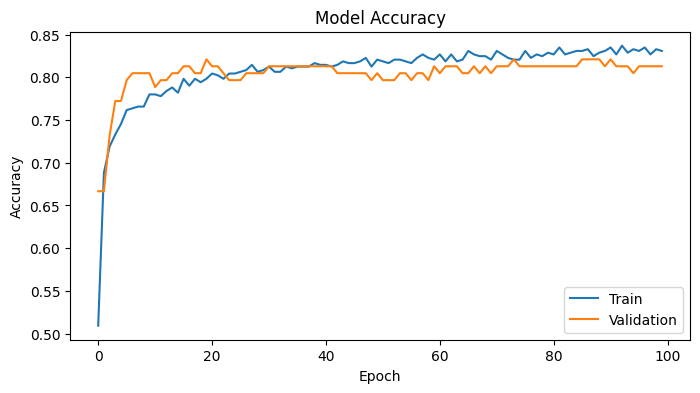

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Input

# 모델링
# 데이터 크기 => 768 기준
# 데이터 천 개 이하 => 1 또는 2개
# 만 개 이하 => 2-3개
# 10만개 이상 3-5 까지.

# 뉴런갯수 
# 컬럼수 4~10 => 8 ~ 32
# 컬럼수 10~50개 =>	16~64개
# 컬럼수 50개 이상 => 32~256개

# 히든레이어는 = 총 데이터수 고려
# 뉴런은 = 총컬럼수 고려

model = Sequential([
    Input(shape=(8,)),  # 총 컬럼 수
    Dense(12,activation="relu"),
    Dense(8,activation="relu"),
    Dense(1,activation="sigmoid")

])

model.summary()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 학습
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=5, # 5개 학습하고 가중치 수정
    validation_split= 0.2,
    verbose=1
)

# 평가
loss, acc = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print()
print("테스트: Loss :",round(loss, 4))
print("테스트 Accuracy :",round(acc, 4))

# 시각화
# 정확도
plt.figure(figsize=(8, 4))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

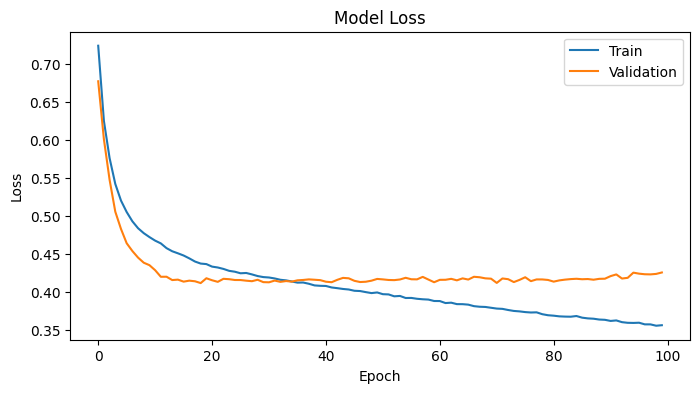

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[[7.58230627e-01]
 [2.55503237e-01]
 [1.28935575e-01]
 [3.79866064e-01]
 [5.98736922e-04]
 [3.08626384e-01]
 [5.91287851e-01]
 [9.78214324e-01]
 [2.00671349e-02]
 [9.44401145e-01]
 [6.71003461e-02]
 [7.58576214e-01]
 [1.13892900e-02]
 [3.85940564e-03]
 [2.63090730e-01]
 [4.51746494e-01]
 [7.93302774e-01]
 [3.54371709e-03]
 [9.72310185e-01]
 [2.53267437e-01]
 [3.91554862e-01]
 [2.68976390e-01]
 [1.62224114e-01]
 [9.83977079e-01]
 [2.37409204e-01]
 [1.30335554e-01]
 [8.03740144e-01]
 [1.03804404e-02]
 [3.16672057e-01]
 [2.71075405e-03]
 [8.52110237e-03]
 [3.39850760e-03]
 [6.72387123e-01]
 [4.51071322e-01]
 [8.87446702e-01]
 [8.88535660e-03]
 [2.39434570e-01]
 [2.03164537e-02]
 [7.76546776e-01]
 [6.17462635e-01]
 [2.98864990e-01]
 [8.01916182e-01]
 [3.64032527e-03]
 [2.28281260e-01]
 [7.56250545e-02]
 [2.03318462e-01]
 [2.26143986e-01]
 [8.06258619e-02]
 [7.74110258e-01]
 [8.98273408e-01]
 [6.66926265e-01]
 [8.80697668e-01]
 [6.77016199e-01]
 [7.1372

c:\Users\user\.conda\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
# loss 그래프

plt.figure(figsize=(8, 4))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

# 예측

pred = model.predict(x_test)
print(pred)

# 새로운 환자 예측

new_patient = np.array([
    [2, 120, 70, 20, 85, 25.0, 0.3, 35]
])

new_patient = scaler.transform(new_patient)

result = model.predict(new_patient)

print()
print("당뇨병 확률 :", round(result[0][0] * 100, 2), "%")

if result[0][0] >= 0.5:
    print("예측 : 당뇨병")
else:
    print("예측 : 정상")